#### Import Packages

In [151]:
from arch import arch_model
import numpy as np
import numba
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import statsmodels.api as sm
import itertools
from statsmodels.tsa.stattools import adfuller

#### Import XLF Data

In [221]:
path = "/Users/joshuawong/Desktop/etf_series.hf5"
data = pd.read_hdf(path,"XLF")
data = data.ffill()
data = data.reset_index()
data['Date'] = pd.to_datetime(data['Date'])
data = data.dropna(subset=['Close'])

#### Import VIX Data and Combine

In [222]:
VIX_path = "/Users/joshuawong/Downloads/data_vix.csv"
VIX_data = pd.read_csv(VIX_path)
VIX_data = VIX_data.ffill()
VIX_data['Date'] = pd.to_datetime(VIX_data['Date'])
VIX_data = VIX_data.dropna(subset=['Adj Close'])
VIX_data = VIX_data[['Date', 'Adj Close']]
VIX_data = VIX_data.rename(columns={'Adj Close': 'VIX Adj Close'})
data1 = data.merge(VIX_data, on='Date', how='inner')
data1 = data1.dropna()

#### Import Bank Prime Rate and Combine

In [223]:
BPR_path = "/Users/joshuawong/Downloads/RIFSPBLPND.csv"
BPR_data = pd.read_csv(BPR_path)
BPR_data = BPR_data.ffill()
BPR_data['DATE'] = pd.to_datetime(BPR_data['DATE'])
BPR_data = BPR_data.rename(columns={'DATE': 'Date','RIFSPBLPND':'Bank Prime Rate'})
BPR_data['Bank Prime Rate'] = BPR_data['Bank Prime Rate']/100
data2 = data1.merge(BPR_data, on='Date', how='inner')
data2 = data2.dropna()

#### Import PCE Data and Combine

In [224]:
PCE_path = "/Users/joshuawong/Downloads/PCE.csv"
PCE_data = pd.read_csv(PCE_path)
PCE_data = PCE_data.ffill()
PCE_data['DATE'] = pd.to_datetime(PCE_data['DATE'])
PCE_data = PCE_data.rename(columns={'DATE': 'Date'})
PCE_data.set_index('Date', inplace=True)
PCE_data = PCE_data.resample('D').ffill()
PCE_data = PCE_data.reset_index()
final_data = data2.merge(PCE_data, on='Date', how='inner')
final_data = final_data.dropna()
final_data = final_data.drop(columns=['Open', 'High', 'Low', 'Close', 'Volume'])
final_data = final_data.rename(columns={'Adj Close': 'XLF Adj Close'})

#### Get Log Returns

In [225]:
final_data.loc[:,'XLF Log Returns'] = np.log(final_data['XLF Adj Close'] / final_data['XLF Adj Close'].shift(1)) * 100
final_data = final_data.dropna(subset=['XLF Log Returns'])
final_data

,Date,XLF Adj Close,VIX Adj Close,Bank Prime Rate,PCE,XLF Log Returns
1,2000-01-04,10.855047,27.010000,0.085,6542.9,-4.470004
2,2000-01-05,10.769754,26.410000,0.085,6542.9,-0.788847
3,2000-01-06,11.242730,25.730000,0.085,6542.9,4.298002
4,2000-01-07,11.428811,21.719999,0.085,6542.9,1.641574
5,2000-01-10,11.227222,21.709999,0.085,6542.9,-1.779605
...,...,...,...,...,...,...
6032,2023-12-22,36.919334,13.030000,0.085,19289.9,0.214495
6033,2023-12-26,37.067646,12.990000,0.085,19289.9,0.400913
6034,2023-12-27,37.186295,12.430000,0.085,19289.9,0.319575
6035,2023-12-28,37.295052,12.470000,0.085,19289.9,0.292038


#### Difference All Data until Stationary

In [226]:
XLF_result = adfuller(final_data['XLF Log Returns'].dropna())
if XLF_result[1] < 0.05:
    print("XLF is stationary")
else:
    print("Difference XLF")

XLF is stationary


In [227]:
VIX_result = adfuller(final_data['VIX Adj Close'].dropna())
if VIX_result[1] < 0.05:
    print("VIX is stationary")
else:
    print("Difference VIX")

VIX is stationary


In [228]:
BPR_result = adfuller(final_data['Bank Prime Rate'].dropna())
if BPR_result[1] < 0.05:
    print("BPR is stationary")
else:
    print("Difference BPR")

Difference BPR


In [229]:
BPR_result1 = adfuller(final_data['Bank Prime Rate'].diff().dropna())
if BPR_result1[1] < 0.05:
    print("BPR is stationary")
else:
    print("Difference BPR")

BPR is stationary


In [230]:
PCE_result = adfuller(final_data['PCE'].dropna())
if PCE_result[1] < 0.05:
    print("PCE is stationary")
else:
    print("Difference PCE")

Difference PCE


In [231]:
PCE_result1 = adfuller(final_data['PCE'].diff().dropna())
if PCE_result1[1] < 0.05:
    print("PCE is stationary")
else:
    print("Difference PCE")

PCE is stationary


In [232]:
final_data['Bank Prime Rate'] = final_data['Bank Prime Rate'].diff()
final_data['PCE'] = final_data['PCE'].diff()
final_data

,Date,XLF Adj Close,VIX Adj Close,Bank Prime Rate,PCE,XLF Log Returns
1,2000-01-04,10.855047,27.010000,NaN,NaN,-4.470004
2,2000-01-05,10.769754,26.410000,0.0,0.0,-0.788847
3,2000-01-06,11.242730,25.730000,0.0,0.0,4.298002
4,2000-01-07,11.428811,21.719999,0.0,0.0,1.641574
5,2000-01-10,11.227222,21.709999,0.0,0.0,-1.779605
...,...,...,...,...,...,...
6032,2023-12-22,36.919334,13.030000,0.0,0.0,0.214495
6033,2023-12-26,37.067646,12.990000,0.0,0.0,0.400913
6034,2023-12-27,37.186295,12.430000,0.0,0.0,0.319575
6035,2023-12-28,37.295052,12.470000,0.0,0.0,0.292038


In [260]:
final_data = final_data.dropna()
final_data['Date'] = pd.to_datetime(final_data['Date'])
final_data.set_index('Date', inplace=True)
final_data

,XLF Adj Close,VIX Adj Close,Bank Prime Rate,PCE,XLF Log Returns
Date,,,,,
2000-01-05,10.769754,26.410000,0.0,0.0,-0.788847
2000-01-06,11.242730,25.730000,0.0,0.0,4.298002
2000-01-07,11.428811,21.719999,0.0,0.0,1.641574
2000-01-10,11.227222,21.709999,0.0,0.0,-1.779605
2000-01-11,11.041133,22.500000,0.0,0.0,-1.671375
...,...,...,...,...,...
2023-12-22,36.919334,13.030000,0.0,0.0,0.214495
2023-12-26,37.067646,12.990000,0.0,0.0,0.400913
2023-12-27,37.186295,12.430000,0.0,0.0,0.319575


#### GARCH Models

##### GARCH(1,1) Model

In [262]:
GARCH_model = arch_model(final_data['XLF Log Returns'], vol='Garch', p=1, q=1, dist='StudentsT')
G_result = GARCH_model.fit(disp="off")
print(G_result.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:              XLF Log Returns   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -9979.79
Distribution:      Standardized Student's t   AIC:                           19969.6
Method:                  Maximum Likelihood   BIC:                           20003.1
                                              No. Observations:                 6035
Date:                      Sun, Oct 27 2024   Df Residuals:                     6034
Time:                              21:01:24   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

##### EGARCH

In [263]:
EGARCH_model = arch_model(final_data['XLF Log Returns'], vol='EGarch', p=1, q=1, dist='StudentsT')
EG_result = EGARCH_model.fit(disp="off")
print(EG_result.summary())

                        Constant Mean - EGARCH Model Results                        
Dep. Variable:              XLF Log Returns   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -9992.85
Distribution:      Standardized Student's t   AIC:                           19995.7
Method:                  Maximum Likelihood   BIC:                           20029.2
                                              No. Observations:                 6035
Date:                      Sun, Oct 27 2024   Df Residuals:                     6034
Time:                              21:01:26   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

##### GARCH-M

In [264]:
GM_model = arch_model(final_data['XLF Log Returns'], vol='Garch', p=1, q=1, mean='Constant', dist='StudentsT')
GM_result = GM_model.fit(disp="off")
print(GM_result.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:              XLF Log Returns   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -9979.79
Distribution:      Standardized Student's t   AIC:                           19969.6
Method:                  Maximum Likelihood   BIC:                           20003.1
                                              No. Observations:                 6035
Date:                      Sun, Oct 27 2024   Df Residuals:                     6034
Time:                              21:01:27   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

##### GARCH-X

In [277]:
ex_data = final_data[['VIX Adj Close', 'Bank Prime Rate', 'PCE']]
GX_model = arch_model(final_data['XLF Log Returns'], vol='Garch', p=1, q=1, x=ex_data, dist='StudentsT')
GX_result = GX_model.fit(disp="off")
print(GX_result.summary())

                        Constant Mean - GARCH Model Results                         
Dep. Variable:              XLF Log Returns   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -9979.79
Distribution:      Standardized Student's t   AIC:                           19969.6
Method:                  Maximum Likelihood   BIC:                           20003.1
                                              No. Observations:                 6035
Date:                      Sun, Oct 27 2024   Df Residuals:                     6034
Time:                              21:06:03   Df Model:                            1
                                 Mean Model                                 
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
mu  

##### AIC Comparison

In [278]:
G_aic = G_result.aic
EG_aic = EG_result.aic
GM_aic = GM_result.aic
GX_aic = GX_result.aic

print(f"GARCH AIC: {G_aic}")
print(f"EGARCH AIC: {EG_aic}")
print(f"GARCH-M AIC: {GM_aic}")
print(f"GARCH-X AIC: {GX_aic}")

GARCH AIC: 19969.577519230916
EGARCH AIC: 19995.694945085022
GARCH-M AIC: 19969.577519230916
GARCH-X AIC: 19969.577519230916


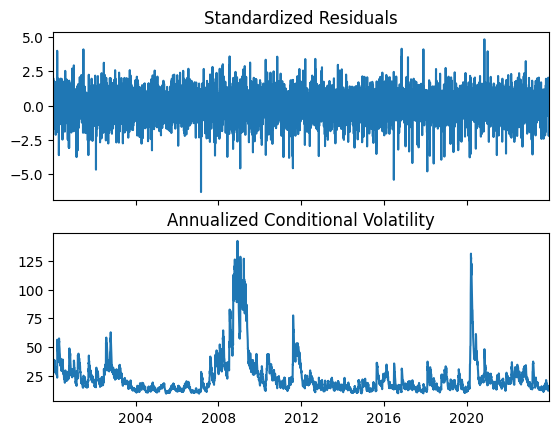

In [279]:
fig = GX_result.plot(annualize="D")

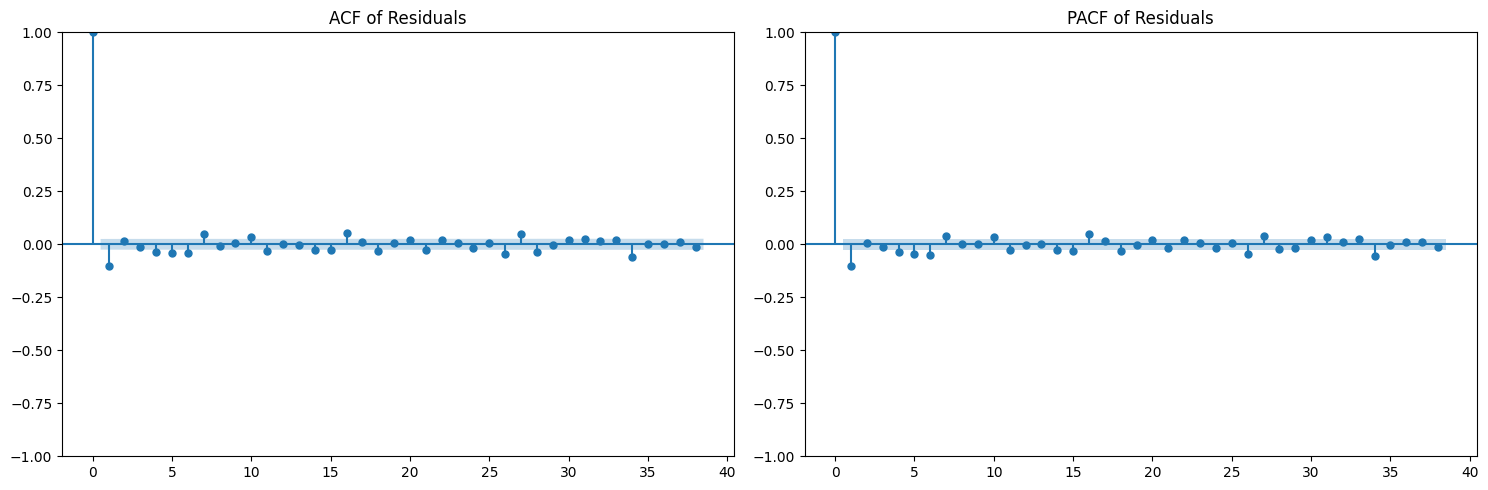

In [280]:
residuals = GX_result.resid
residuals = residuals[~np.isnan(residuals)]

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
sm.graphics.tsa.plot_acf(residuals, ax=axs[0])
axs[0].set_title('ACF of Residuals')

sm.graphics.tsa.plot_pacf(residuals, ax=axs[1])
axs[1].set_title('PACF of Residuals') 

plt.tight_layout()
plt.show()

In [275]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(residuals, lags=[10], return_df=True)
p_value = lb_test['lb_pvalue']
if (p_value < 0.05).any():
    print("Residuals are heteroscedastic at 5% level of confidence")
else:
    print("Residuals are homoscedastic at 5% level of confidence")

Residuals are heteroscedastic at 5% level of confidence


In [286]:
lb_test

,lb_stat,lb_pvalue
10,115.119652,4.932305e-20


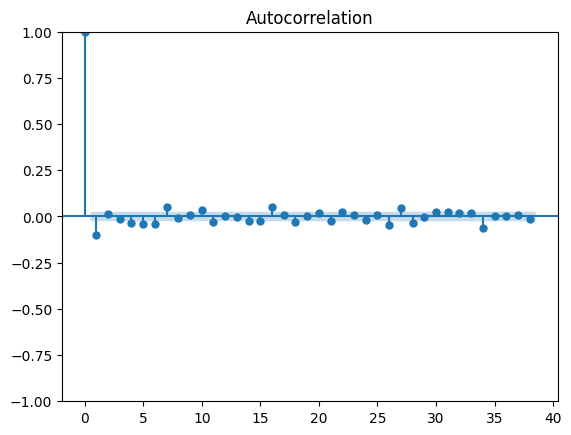

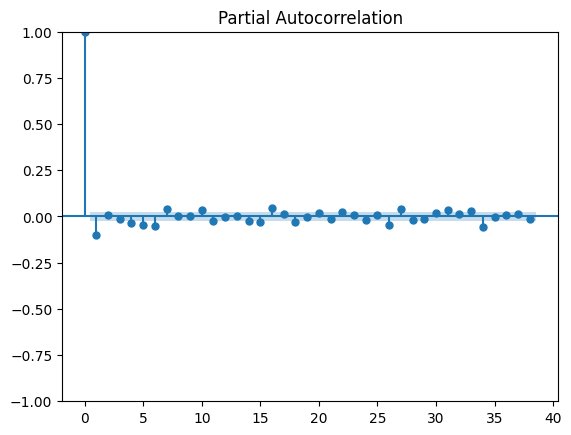

In [276]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(residuals)
plot_pacf(residuals)
plt.show()

#### Actual Implied Volatility

<Axes: xlabel='Date'>

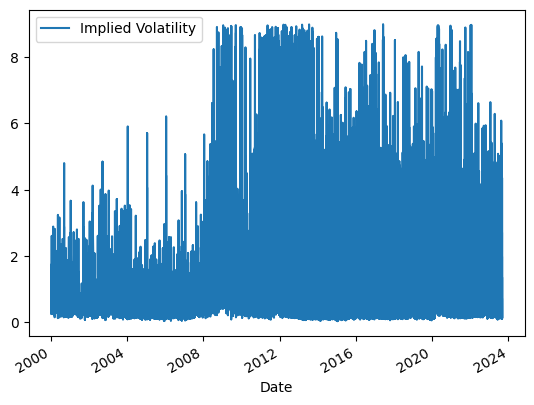

In [285]:
IV_path = "/Users/joshuawong/Desktop/etf_options_data.hf5"
IV_data = pd.read_hdf(IV_path,"XLF")
IV_data['date'] = pd.to_datetime(IV_data['date'])
IV_data = IV_data.rename(columns={'impl_volatility': 'Implied Volatility','date':'Date'})
IV_data = IV_data[['Date','Implied Volatility']]
IV_data = IV_data.dropna()
IV_data.set_index('Date', inplace=True)
IV_data.plot()